In [2]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import norm
import pandas as pd
from scipy import stats
from itertools import product
from scipy import linalg
from functools import partial

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork, BernoulliNetwork

from src.helper_functions.plot_functions import visualise_latent

In [3]:
rng = np.random.default_rng(42)
copula_types = ['gaussian', 'gaussian', 'gaussian', 'frank', 'rotated_clayton', 'mixture_uniform']

params = {
    'copula_type' : ['gaussian', 'clayton', 'gumbel', 'frank',
                     'gaussian', 'clayton', 'gumbel', 'frank',
                     'gaussian', 'clayton', 'gumbel', 'frank',
                     'gaussian', 'clayton', 'gumbel', 'frank',
                     'mixture_uniform', 'mixture_uniform', 'mixture_uniform', 'mixture_uniform'
                     ],

    'marginals' : ['gaussian', 'gaussian', 'gaussian', 'gaussian',
                   't 5', 't 5', 't 5', 't 5',
                   'uniform -5 5', 'uniform -5 5', 'uniform -5 5', 'uniform -5 5',
                   'cauchy', 'cauchy', 'cauchy', 'cauchy',
                   'gaussian', 't 5', 'uniform -5 5', 'cauchy'
                   ],
    'weights' : [[], [], [],[],
                 [], [], [],[],
                 [], [], [],[],
                 [], [], [],[],
                [0.5, 0.5], [0.5, 0.5],[0.5, 0.5],[0.5, 0.5]
                 ],
    
    'correlations' : [[], [], [], [],
                      [], [], [], [],
                      [], [], [], [],
                      [], [], [], [],
                      [0.98, -0.98],[0.98, -0.98], [0.98, -0.98], [0.98, -0.98],
                      ],
    
    'titles': ['Gaussian gaussian', 'gaussian clayton', 'gaussian gumbel', 'gaussian frank',
               't gaussian', 't clayton', 't gumbel', 't frank',
               'uniform gaussian', 'uniform clayton', 'uniform gumbel', 'uniform frank',
               'cauchy gaussian', 'cauchy clayton', 'cauchy gumbel', 'cauchy frank',
               'gaussian mixture', 't mixture', 'uniform mixture', 'cauchy mixture'
               ],
    'rho': [0.75, 0.75, 0.75, 0.75,  
            0.75, 0.75, 0.75, 0.75,
            0.75, 0.75, 0.75, 0.75,
            0.75, 0.75, 0.75, 0.75,
            0.75, 0.75, 0.75, 0.75]
}


X_list, Z_list = [], []

for (copula_type, marginals, weights, correlations, rho) in zip(params['copula_type'], params['marginals'], params['weights'], params['correlations'], params['rho']):
    m = GaussianNetwork(n=1000, k=3, rho=rho, rng=rng, 
                        copula_model=copula_type, marginals=marginals,
                        weights=weights, correlations=correlations
                        )
    data = m.generate()
    X_list.append(data['X'])
    Z_list.append(data['Z'])

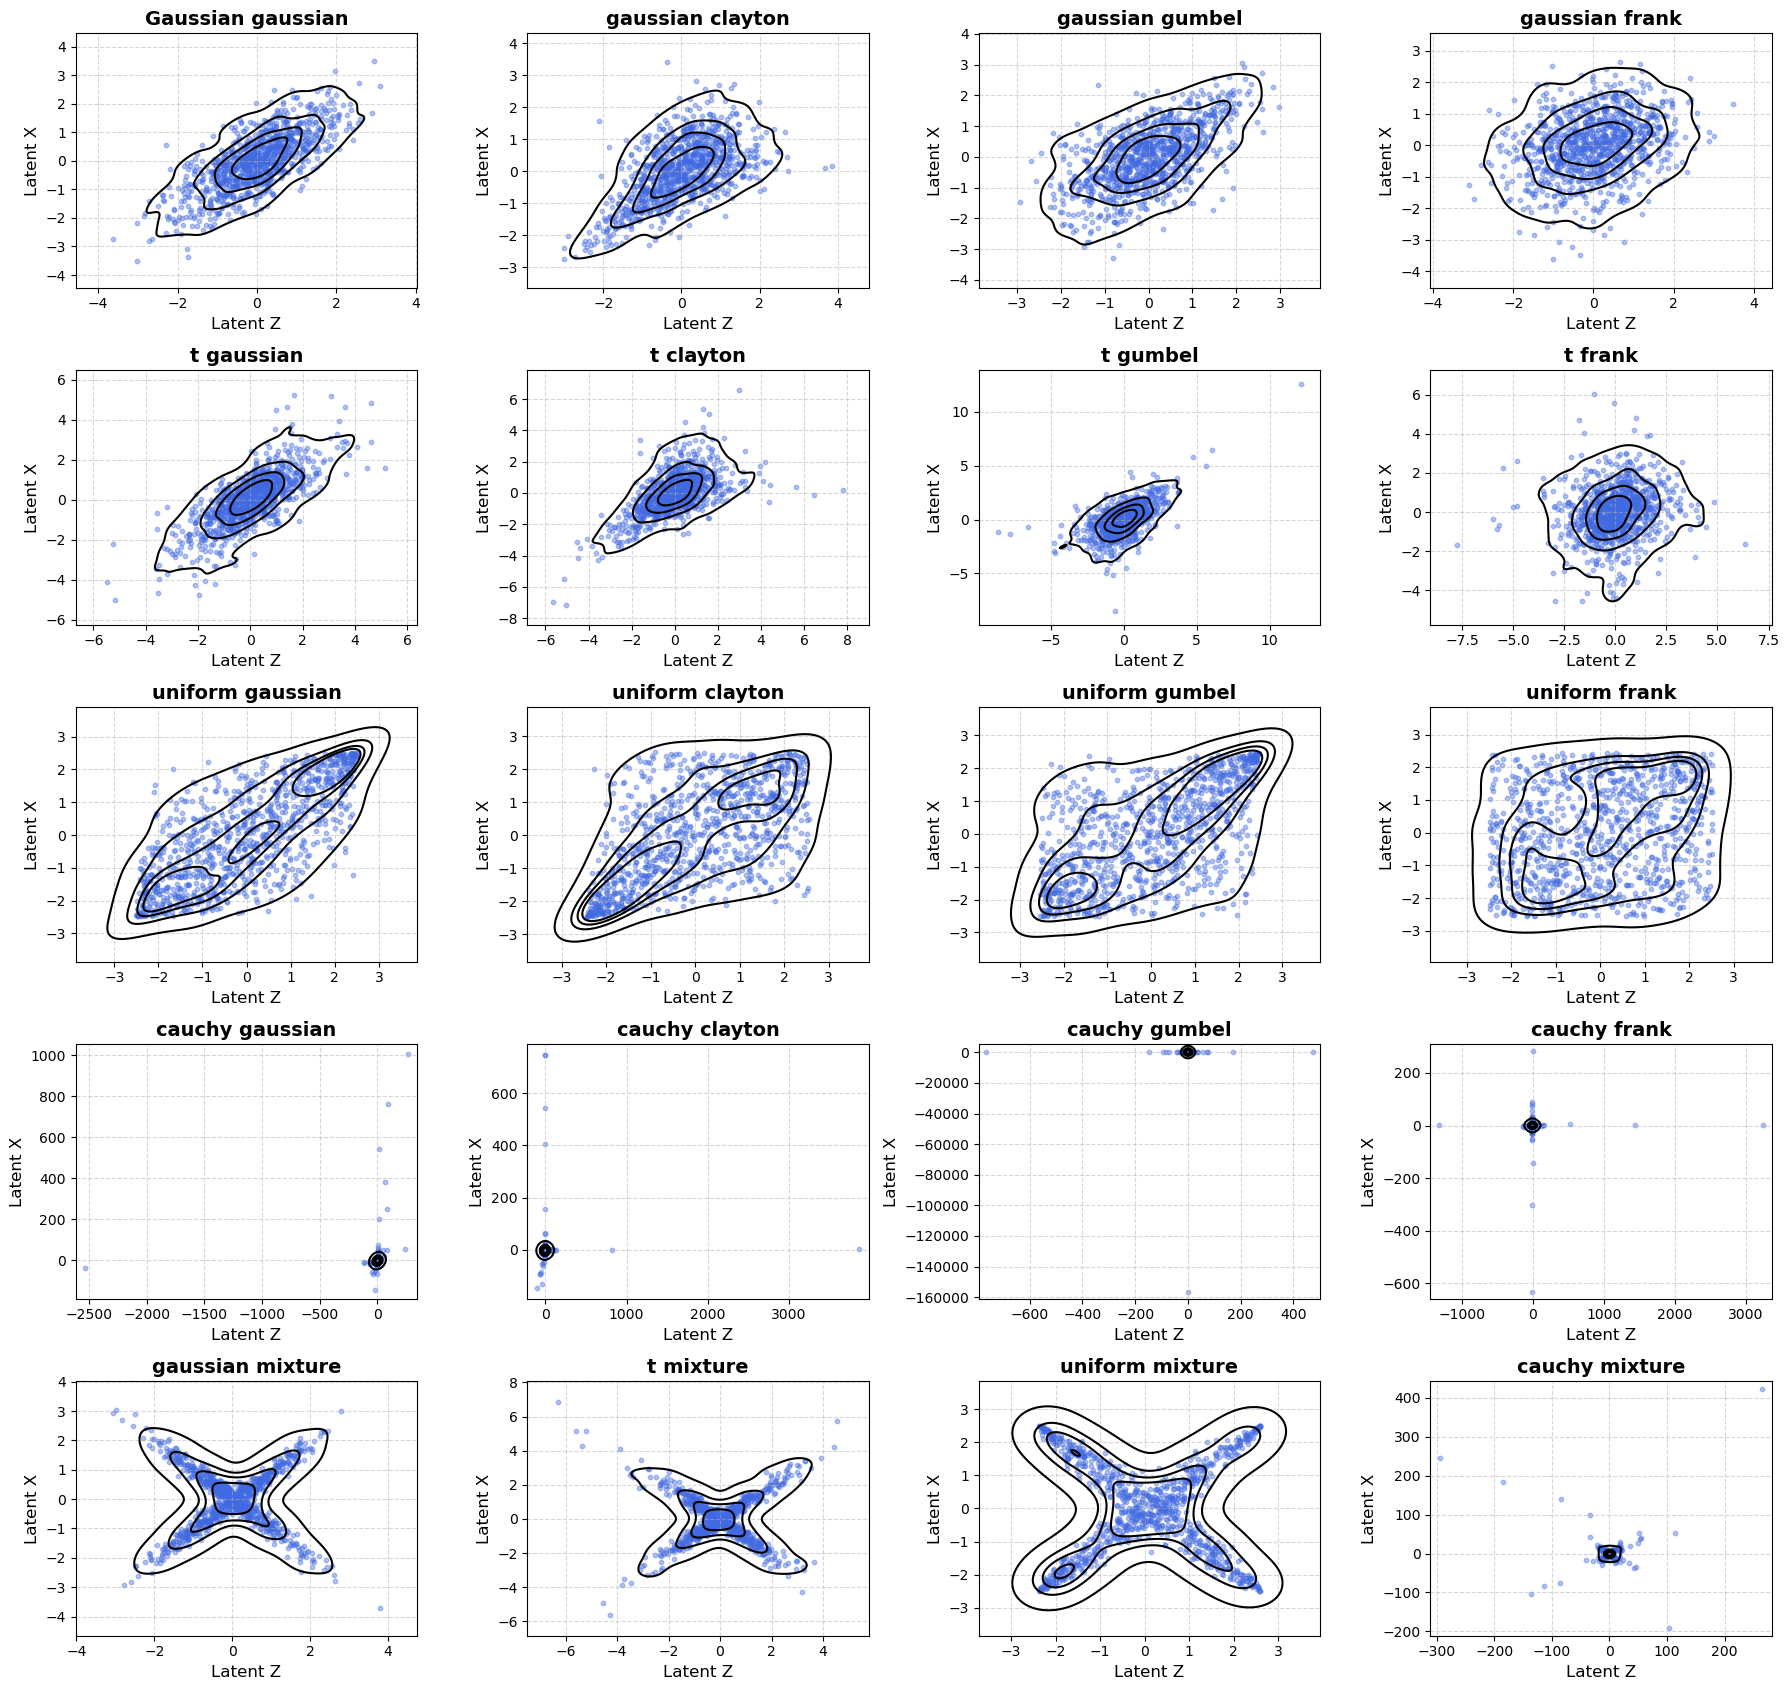

In [8]:
visualise_latent(Z_list, X_list, titles=params['titles'], 
                 shape=(5, 4), figsize=(18, 17), k=1, 
                 kdplot=True, sharex=False, sharey=False)

In [ ]:
# visualise_latent(Z_list, X_list, titles=params['titles'], 
#                  shape=(2, 5), figsize=(18, 7), k=1, 
#                  kdplot=True, sharex=False, sharey=False, save_path='visualise_latent')